In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import Image, display

# Initialize GEE
try:
    ee.Initialize(project='replicating-paper') # Replace with your project ID if needed
    print("Google Earth Engine Initialized successfully.")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()
    print("Google Earth Engine Authenticated and Initialized.")

Google Earth Engine Initialized successfully.


In [3]:
# --- 1. DEFINE ROI ---
# Sanjay Van, Delhi (Static Bounds)
roi = ee.Geometry.Rectangle([77.17, 28.52, 77.18, 28.54])

# --- 2. TIME WINDOWS ---
# We use a 3-year window to smooth out cloud gaps for phenology
START_DATE = '2022-01-01'
END_DATE = '2024-12-31'
SCALE = 10  # 10 meters (Sentinel-2 Native Res)

print(f"Region: Sanjay Van")
print(f"Time Window: {START_DATE} to {END_DATE}")
print(f"Analysis Scale: {SCALE} meters")

Region: Sanjay Van
Time Window: 2022-01-01 to 2024-12-31
Analysis Scale: 10 meters


In [4]:
print("--- PHASE 1: COARSE FILTERING ---")

# 1. NIGHT LIGHTS (Urban Pressure)
# We use VIIRS to find bright urban spots (Roads/Parking Lots)
viirs = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate(START_DATE, END_DATE) \
    .select('avg_rad').mean().clip(roi).rename('Night_Lights')

# 2. SURFACE WATER (Hydrology)
# JRC Global Surface Water to mask out permanent ponds/lakes
water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater") \
    .clip(roi).select('occurrence').rename('Water_Occurrence')

# 3. BASIC GREENNESS (NDVI Baseline)
# Quick median composite to find "Is it green at all?"
s2_basic = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi) \
    .filterDate(START_DATE, END_DATE) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median().clip(roi)

ndvi_basic = s2_basic.normalizedDifference(['B8', 'B4']).rename('NDVI_Base')

# --- DIAGNOSTIC: Check values in Sanjay Van ---
# This tells us if our thresholds are unrealistic for this specific location
stats = viirs.addBands(ndvi_basic).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=30,
    maxPixels=1e9
).getInfo()
print(f"Diagnostics for ROI:")
print(f"   - Avg Night Light (Radiance): {stats.get('Night_Lights'):.2f} (Threshold is 30.0)")
print(f"   - Avg NDVI: {stats.get('NDVI_Base'):.2f} (Threshold is 0.2)")

# --- CREATE MASKS ---
# Define thresholds (Adjust these based on your specific biome)
light_threshold = 30.0   # High lights = Urban
water_threshold = 10.0   # >10% water recurrence = Pond
ndvi_threshold = 0.2     # <0.2 = Bare Soil/Concrete

# Create Binary Masks
is_dark = viirs.lt(light_threshold)
is_land = water.lt(water_threshold)
is_green = ndvi_basic.gt(ndvi_threshold)

# Final Phase 1 Mask: Must be Dark AND Land AND Green
phase1_mask = is_dark.And(is_land).And(is_green)

print("Phase 1 Layers Loaded.")
print(f"   - Night Lights (Urban removal)")
print(f"   - JRC Water (Pond removal)")
print(f"   - NDVI Baseline (Soil removal)")

# Visual Check (Static Snapshot)
print("Generating Mask Snapshot...")
mask_vis = phase1_mask.visualize(min=0, max=1, palette=['red', 'green'])
try:
    thumb_url = mask_vis.getThumbURL({
        'dimensions': 600,
        'region': roi, # Passing the geometry object directly
        'format': 'png'
    })
    print(f"Click to open image: {thumb_url}")
    display(Image(url=thumb_url))
    print("(Red = Ignored / Green = Passed to Phase 2)")

except Exception as e:
    print(f"Error generating thumbnail: {e}")

--- PHASE 1: COARSE FILTERING ---
Diagnostics for ROI:
   - Avg Night Light (Radiance): 19.84 (Threshold is 30.0)
   - Avg NDVI: 0.52 (Threshold is 0.2)
Phase 1 Layers Loaded.
   - Night Lights (Urban removal)
   - JRC Water (Pond removal)
   - NDVI Baseline (Soil removal)
Generating Mask Snapshot...
Click to open image: https://earthengine.googleapis.com/v1/projects/replicating-paper/thumbnails/5bc6727b22b9efa9051651637af4053a-5519845c4708999fdb212229d859bc22:getPixels


(Red = Ignored / Green = Passed to Phase 2)


In [5]:
# --- VISUALIZE WITH GEEMAP (INTERACTIVE) ---
Map = geemap.Map()

# 1. Center the map on Sanjay Van
Map.centerObject(roi, 14)

# 2. Add the ROI outline (Blue) so you know exactly where the boundary is
Map.addLayer(roi, {'color': 'blue'}, "Sanjay Van ROI")

# 3. Add the 'Night Lights' layer (just to see where the city pressure is)
vis_night = {'min': 0, 'max': 60, 'palette': ['black', 'purple', 'cyan', 'white']}
Map.addLayer(viirs, vis_night, "Night Lights (Raw)", False) # Hidden by default

# 4. Add your Final Mask
# We use .updateMask() so that '0' (Ignored) pixels are transparent
# Only '1' (Suitable) pixels will appear as bright GREEN.
final_vis = phase1_mask.updateMask(phase1_mask)
Map.addLayer(final_vis, {'palette': ['00FF00']}, "Phase 1: Suitable Habitat (Green)")

# 5. Display
Map

Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
import ee
import geemap

Map = geemap.Map()
print("--- PHASE 1: DEBUGGING & FIXING ---")

# 1. LAND COVER (ESA WorldCover) - KEPT (You confirmed this works)
worldcover = ee.ImageCollection("ESA/WorldCover/v100").first().clip(roi)
land_classification = worldcover.select('Map')
# Allow Trees (10), Shrubland (20), Grassland (30)
is_vegetation_class = land_classification.eq(10) \
    .Or(land_classification.eq(20)) \
    .Or(land_classification.eq(30))

# 2. SURFACE WATER (The Likely Fix)
# We add .unmask(0) to ensure "No Data" pixels are treated as "Land"
water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater") \
    .clip(roi).select('occurrence').unmask(0)  # <--- CRITICAL FIX
is_land = water.lt(10.0)

# 3. GREENNESS (The Seasonality Fix)
# Instead of 'median' (which might be brown/dry), we take the GREENEST pixel
# from the entire 3-year period (Greenest Pixel Composite).
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi) \
    .filterDate(START_DATE, END_DATE) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(lambda img: img.addBands(img.normalizedDifference(['B8', 'B4']).rename('ndvi')))

# We sort by NDVI and pick the top one (Greenest state of the forest)
greenest_pixel = s2.qualityMosaic('ndvi').clip(roi)
ndvi_greenest = greenest_pixel.select('ndvi')

# We can now safely use a higher threshold because we are looking at peak greenness
is_green = ndvi_greenest.gt(0.3)

# --- COMBINE MASKS ---
phase1_mask = is_vegetation_class.And(is_land).And(is_green)

print("Phase 1 Fixed:")
print("   - JRC Water: Added .unmask(0) to prevent deleting dry land.")
print("   - NDVI: Switched to 'Greenest Pixel' to ignore dry season browning.")

# --- DIAGNOSTIC VISUALIZATION ---
Map.centerObject(roi, 14)

# Layer 1: The Base Image (Greenest View)
Map.addLayer(greenest_pixel, {'bands':['B4', 'B3', 'B2'], 'min':0, 'max':3000}, "Greenest Satellite View")

# Layer 2: The Raw ESA Layer (For Reference)
Map.addLayer(land_classification, {}, "ESA Classification (Raw)", False)

# Layer 3: THE FINAL MASK (Neon Green)
final_vis = phase1_mask.updateMask(phase1_mask)
Map.addLayer(final_vis, {'palette': ['00FF00']}, "Final Suitable Habitat Mask")

# Layer 4: Debug - Show me what failed NDVI (Red)
# This shows pixels that are ESA-Forest but NOT Green enough
failed_ndvi = is_vegetation_class.And(is_green.Not()).updateMask(is_vegetation_class.And(is_green.Not()))
Map.addLayer(failed_ndvi, {'palette': ['red']}, "Debug: ESA Forest but Low NDVI (Red)", False)

Map

--- PHASE 1: DEBUGGING & FIXING ---
Phase 1 Fixed:
   - JRC Water: Added .unmask(0) to prevent deleting dry land.
   - NDVI: Switched to 'Greenest Pixel' to ignore dry season browning.


Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
import math

print("--- PHASE 2: ECOLOGICAL STACKING (Dimensions Fixed) ---")

# --- HELPER FUNCTIONS ---

def get_sentinel1():
    """Loads Sentinel-1 and converts to Decibels manually."""
    s1 = ee.ImageCollection("COPERNICUS/S1_GRD") \
        .filterBounds(roi) \
        .filterDate(START_DATE, END_DATE) \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
        .filter(ee.Filter.eq('instrumentMode', 'IW'))

    def to_db(img):
        # Convert VH amplitude to Decibels (10*log10)
        # We add a small epsilon (1e-5) to avoid log(0) errors
        vh_db = ee.Image(10).multiply(img.select('VH').pow(2).log10()).rename('S1_VH')
        return vh_db

    return s1.map(to_db).mean().clip(roi)

def get_canopy_height():
    """Attempts to load ETH Global Canopy Height, falls back to Dynamic World."""
    try:
        ch = ee.Image("users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1").select('b1')
        print("Using ETH Global Canopy Height (10m)")
        return ch.rename('Canopy_Height').clip(roi)
    except:
        print("ETH Height not accessible. Using Dynamic World 'Tree Probability' as proxy.")
        dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
            .filterBounds(roi).filterDate(START_DATE, END_DATE) \
            .select('trees').mean()
        return dw.rename('Canopy_Height').clip(roi)

def min_max_scale(image, bands, region):
    """Normalizes bands to 0-1 range."""
    stats = image.reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=region,
        scale=30,
        maxPixels=1e9
    )

    normalized = ee.Image(0)
    for band in bands:
        min_val = ee.Number(stats.get(f'{band}_min'))
        max_val = ee.Number(stats.get(f'{band}_max'))
        range_val = max_val.subtract(min_val)

        # Normalize: (val - min) / (max - min)
        norm_band = image.select(band).subtract(min_val).divide(range_val)
        normalized = normalized.addBands(norm_band.rename(band))

    return normalized.select(bands)

# --- 1. PHENOLOGY (Sentinel-2 Harmonics) ---
print("Computing Phenology (Harmonics)...")

def add_harmonics(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    time_diff = image.date().difference(ee.Date(START_DATE), 'year')
    t = ee.Image.constant(time_diff).multiply(2 * math.pi)
    cos = t.cos().rename('cos')
    sin = t.sin().rename('sin')
    const = ee.Image.constant(1).rename('const')
    return image.addBands([ndvi, cos, sin, const])

def mask_s2_clouds(image):
    qa = image.select('QA60')
    mask = qa.bitwiseAnd(1<<10).eq(0).And(qa.bitwiseAnd(1<<11).eq(0))
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi).filterDate(START_DATE, END_DATE) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(mask_s2_clouds).map(add_harmonics)

# --- THE FIX IS HERE ---
# We use .arrayProject([0]) to convert the 3x1 output into a 1D array of length 3
harmonics = s2_collection.select(['const', 'cos', 'sin', 'NDVI']) \
    .reduce(ee.Reducer.linearRegression(3, 1)) \
    .select('coefficients') \
    .arrayProject([0]) \
    .arrayFlatten([['const', 'cos', 'sin']])

ndvi_mean = harmonics.select('const').rename('NDVI_Mean')
ndvi_amp = harmonics.select('cos').hypot(harmonics.select('sin')).rename('NDVI_Amp')
ndvi_phase = harmonics.select('sin').atan2(harmonics.select('cos')).rename('NDVI_Phase')

# --- 2. STRUCTURE & NICHE ---
print("Loading Structure & Topography...")
s1_vh = get_sentinel1()
canopy_h = get_canopy_height()
dem = ee.Image("NASA/NASADEM_HGT/001").clip(roi)
elevation = dem.select('elevation').rename('Elevation')
slope = ee.Terrain.slope(elevation).rename('Slope')

# --- 3. MERGE & NORMALIZE ---
print("Stacking and Normalizing...")
raw_stack = ee.Image.cat([ndvi_mean, ndvi_amp, ndvi_phase, canopy_h, s1_vh, slope, elevation]) \
    .updateMask(phase1_mask)

band_names = raw_stack.bandNames().getInfo()
master_stack = min_max_scale(raw_stack, band_names, roi).toFloat()

print("Master Stack Built & Normalized.")
print(f"   Bands: {band_names}")

--- PHASE 2: ECOLOGICAL STACKING (Dimensions Fixed) ---
Computing Phenology (Harmonics)...
Loading Structure & Topography...
Using ETH Global Canopy Height (10m)
Stacking and Normalizing...
Master Stack Built & Normalized.
   Bands: ['NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height', 'S1_VH', 'Slope', 'Elevation']


In [8]:
print("--- PRE-PROCESSING (Advanced) ---")

# 1. Log Transform skewed features
# CRITICAL: We use 'raw_stack' (Physical units) not 'master_stack' (0-1 scaled)
print("Applying Log Transform to Height & Slope...")

# Note: We use .max(0) to ensure we don't carry over any negative errors before logging
ch_log = raw_stack.select('Canopy_Height').max(0).add(1).log10().rename('Canopy_Height_Log')
slope_log = raw_stack.select('Slope').max(0).add(1).log10().rename('Slope_Log')

# Replace original bands with Log versions
# We explicitly select 'S1_VH' (from Phase 2 output) NOT 'S1_VH_Mean'
analysis_stack = raw_stack.addBands([ch_log, slope_log], overwrite=True) \
    .select(['NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height_Log', 'S1_VH', 'Slope_Log'])

# 2. Z-Score Normalization
# This centers everything at 0 with a standard deviation of 1
print("Normalizing Data (Z-Score)...")

stats = analysis_stack.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
    geometry=roi,
    scale=10,  # Use 10m to match your sensors
    bestEffort=True,
    maxPixels=1e9
)

# Apply (Image - Mean) / StdDev
norm_bands = []
for band in analysis_stack.bandNames().getInfo():
    mean = ee.Number(stats.get(f'{band}_mean'))
    std = ee.Number(stats.get(f'{band}_stdDev'))

    # Check for constant bands (stdDev = 0) to avoid divide by zero
    # If std is 0, we just subtract mean (centering)
    norm_img = ee.Image(ee.Algorithms.If(
        std.neq(0),
        analysis_stack.select(band).subtract(mean).divide(std),
        analysis_stack.select(band).subtract(mean)
    )).rename(band)

    norm_bands.append(norm_img)

# Update master_stack with this new, superior version
master_stack = ee.Image.cat(norm_bands).updateMask(phase1_mask)

print("Data Transformed & Normalized.")
print(f"   Bands: {master_stack.bandNames().getInfo()}")

--- PRE-PROCESSING (Advanced) ---
Applying Log Transform to Height & Slope...
Normalizing Data (Z-Score)...
Data Transformed & Normalized.
   Bands: ['NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height_Log', 'S1_VH', 'Slope_Log']


In [9]:
print("--- PHASE 2 EXECUTION: OBJECT-BASED CLUSTERING ---")

# --- 1. SNIC SEGMENTATION (The Grouping Step) ---
print("Running SNIC Segmentation (Object-Based)...")

# CRITICAL CHANGE: Reduced seed spacing from 10 (100m) to 5 (50m)
# This captures finer ecological patches while still reducing noise.
seeds = ee.Algorithms.Image.Segmentation.seedGrid(5)

snic = ee.Algorithms.Image.Segmentation.SNIC(
    image=master_stack, # Use the Z-Score Normalized Stack
    compactness=0.5,        # 0 = irregular shapes (pure spectral), 1 = square shapes
    connectivity=8,
    neighborhoodSize=128,
    seeds=seeds
)

# We select the 'mean' bands. These are the "Averaged" values for each patch.
# SNIC appends '_mean' to the band names automatically.
object_means = snic.select(['.*_mean'])

# --- 2. K-MEANS CLUSTERING (The Classification Step) ---
K_CLUSTERS = 6
print(f"Clustering objects into {K_CLUSTERS} Ecological Stands...")

# Sample the OBJECTS, not the raw pixels
training_data = object_means.sample(
    region=roi,
    scale=SCALE,
    numPixels=5000,
    geometries=True
)

# Train & Cluster
clusterer = ee.Clusterer.wekaKMeans(K_CLUSTERS).train(training_data)
result_clusters = object_means.cluster(clusterer).rename('Eco_Cluster')

# Remap and Mask
final_map = result_clusters.updateMask(phase1_mask)

# --- 3. VISUALIZATION ---
print("Visualizing Results...")
Map.centerObject(roi, 14)

# Layer 1: The Raw Segments (Visual Check)
# This creates random colors for every 'cell' so you can see the segment size
segment_vis = snic.select('clusters').randomVisualizer()
Map.addLayer(segment_vis, {}, "Debug: SNIC Segments (The 'Cells')", False)

# Layer 2: The Final Clusters
cluster_vis = {'min': 0, 'max': K_CLUSTERS-1, 'palette': [
    'red', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'lightgreen'
]}
Map.addLayer(final_map, cluster_vis, "Final Ecological Clusters (SNIC)")

print("Clustering Complete.")
Map

--- PHASE 2 EXECUTION: OBJECT-BASED CLUSTERING ---
Running SNIC Segmentation (Object-Based)...
Clustering objects into 6 Ecological Stands...
Visualizing Results...
Clustering Complete.


Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

--- PHASE 3: INTERPRETATION & PROFILING (Merged) ---
Calculating Zonal Statistics...

ECOLOGICAL STAND PROFILE:
ID  | HEIGHT (m) | SLOPE (deg)  | SEASONALITY     | RADAR (dB) | INTERPRETATION
-----------------------------------------------------------------------------------------------
0   | 1.59       | 3.77         | 0.112           | 22.41      | Dense Deciduous Scrub/Grass (Flat)
1   | 10.69      | 4.83         | 0.082           | 22.56      | Dense Evergreen Tall Forest (Flat)
2   | 6.34       | 4.78         | 0.112           | 22.40      | Dense Deciduous Low Tree/Shrub (Flat)
3   | 11.62      | 1.92         | 0.075           | 22.59      | Dense Evergreen Tall Forest (Flat)
4   | 12.59      | 3.66         | 0.061           | 22.68      | Dense Evergreen Tall Forest (Flat)
5   | 13.02      | 4.32         | 0.049           | 22.58      | Dense Evergreen Tall Forest (Flat)


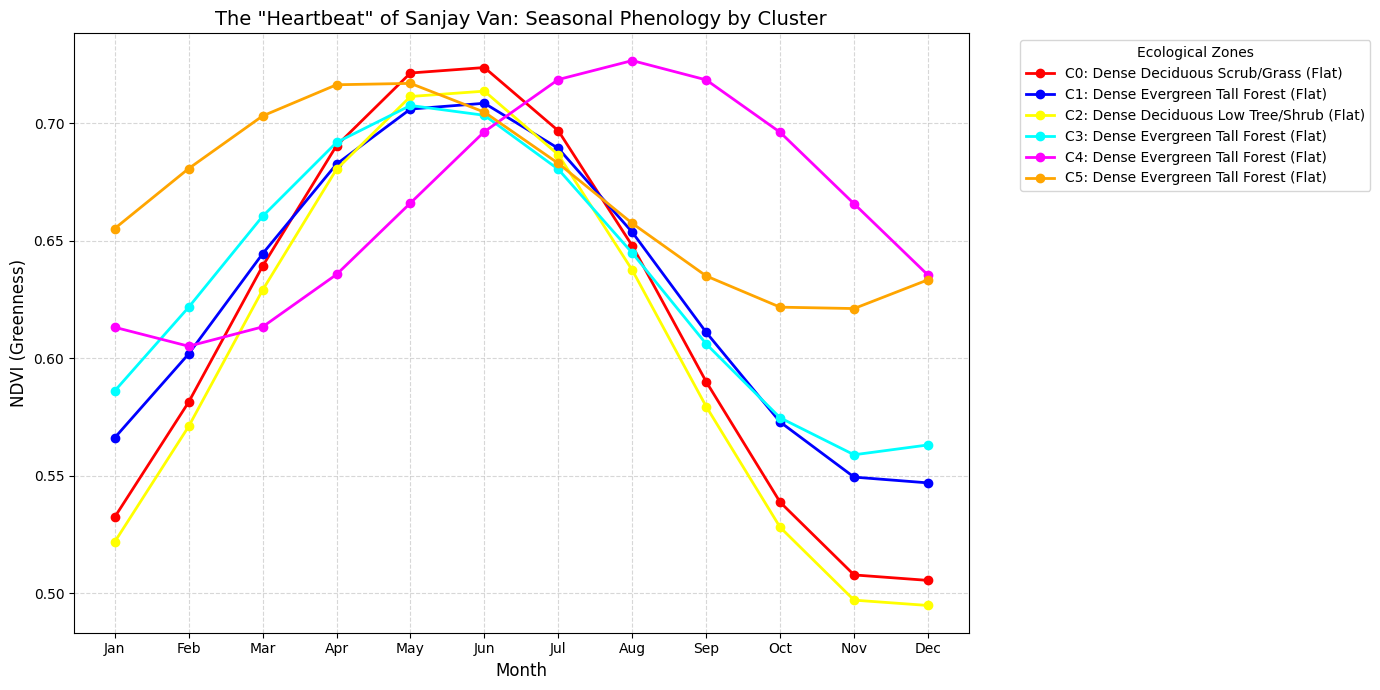

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- PHASE 3: INTERPRETATION & PROFILING (Merged) ---")

# 1. Prepare Data (Use RAW STACK for physical units)
# We explicitly select the bands we need for the report
target_bands = ['NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height', 'Slope', 'S1_VH']
interpretation_stack = raw_stack.select(target_bands).addBands(result_clusters)

# 2. Calculate Stats Safely
print("Calculating Zonal Statistics...")
stats_list = []

# We loop through clusters to ensure we get the correct data mapping
# (Slightly slower than .group() but 100% immune to column shuffling errors)
for i in range(K_CLUSTERS):
    # Create a mask for just this cluster
    cluster_mask = result_clusters.eq(i)

    # Reduce the RAW stack for this cluster area
    means = interpretation_stack.updateMask(cluster_mask).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).getInfo()

    means['Cluster_ID'] = i
    stats_list.append(means)

# Convert to DataFrame for easy handling
df_stats = pd.DataFrame(stats_list).sort_values('Cluster_ID')

# 3. VISUALIZATION & REPORTING
months = np.arange(1, 13)
# Convert months to radians for the sine wave (Month 1 = Jan)
time_radians = (months - 0.5) / 12 * 2 * np.pi

plt.figure(figsize=(14, 7))
cluster_colors = ['red', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'lightgreen']

print("\nECOLOGICAL STAND PROFILE:")
print(f"{'ID':<3} | {'HEIGHT (m)':<10} | {'SLOPE (deg)':<12} | {'SEASONALITY':<15} | {'RADAR (dB)':<10} | {'INTERPRETATION'}")
print("-" * 95)

for index, row in df_stats.iterrows():
    c_id = int(row['Cluster_ID'])

    # Safe Value Extraction (By Name)
    mean = row['NDVI_Mean']
    amp = row['NDVI_Amp']
    phase = row['NDVI_Phase']
    h = row['Canopy_Height']
    s = row['Slope']
    radar = row['S1_VH']

    # --- AUTO-LABELING LOGIC ---
    label = "Unknown"

    # 1. Structure Logic
    if h < 2.0:
        struct = "Scrub/Grass"
    elif h < 8.0:
        struct = "Low Tree/Shrub"
    else:
        struct = "Tall Forest"

    # 2. Terrain Logic
    if s > 10.0:
        terrain = " (Slope)"
    else:
        terrain = " (Flat)"

    # 3. Phenology Logic
    # High Amplitude = Big difference between Summer/Winter (Deciduous)
    if amp > 0.10:
        pheno = "Deciduous"
    else:
        pheno = "Evergreen"

    # Special Case: Radar Check for Density
    # High Backscatter (> -12 dB) usually means dense, woody branches
    density = ""
    if radar > -12:
        density = "Dense "
    elif radar < -18:
        density = "Open "

    label = f"{density}{pheno} {struct}{terrain}"

    # Print Table Row
    print(f"{c_id:<3} | {h:<10.2f} | {s:<12.2f} | {amp:<15.3f} | {radar:<10.2f} | {label}")

    # --- PHENOLOGY CURVE ---
    # Formula: NDVI(t) = Mean + Amp * cos(t - Phase)
    curve = mean + amp * np.cos(time_radians - phase)

    # Plot
    plt.plot(months, curve, marker='o', linewidth=2, label=f"C{c_id}: {label}", color=cluster_colors[c_id % len(cluster_colors)])

# Final Polish
plt.title('The "Heartbeat" of Sanjay Van: Seasonal Phenology by Cluster', fontsize=14)
plt.ylabel('NDVI (Greenness)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(months, ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Ecological Zones")
plt.tight_layout()
plt.show()

In [11]:
print("\nMONTHLY PHENOLOGY DATA (For Excel/Plotting):")
print(f"{'Cluster':<8} | {'Jan':<5} | {'Feb':<5} | {'Mar':<5} | {'Apr':<5} | {'May':<5} | {'Jun':<5} | {'Jul':<5} | {'Aug':<5} | {'Sep':<5} | {'Oct':<5} | {'Nov':<5} | {'Dec':<5}")
print("-" * 95)

# Re-calculate the curves to print the values
for index, row in df_stats.iterrows():
    c_id = int(row['Cluster_ID'])
    mean = row['NDVI_Mean']
    amp = row['NDVI_Amp']
    phase = row['NDVI_Phase']

    # Calculate 12 monthly points
    monthly_vals = []
    for month_idx in range(12): # 0=Jan, 11=Dec
        # We use (month_idx + 1) to match the plotting math
        m_rad = ((month_idx + 1) - 0.5) / 12 * 2 * np.pi
        val = mean + amp * np.cos(m_rad - phase)
        monthly_vals.append(val)

    # Format and Print
    vals_str = " | ".join([f"{v:.3f}" for v in monthly_vals])
    print(f"Cluster {c_id:<1} | {vals_str}")


MONTHLY PHENOLOGY DATA (For Excel/Plotting):
Cluster  | Jan   | Feb   | Mar   | Apr   | May   | Jun   | Jul   | Aug   | Sep   | Oct   | Nov   | Dec  
-----------------------------------------------------------------------------------------------
Cluster 0 | 0.532 | 0.581 | 0.639 | 0.690 | 0.721 | 0.724 | 0.697 | 0.648 | 0.590 | 0.539 | 0.508 | 0.506
Cluster 1 | 0.566 | 0.602 | 0.644 | 0.683 | 0.706 | 0.708 | 0.689 | 0.654 | 0.611 | 0.573 | 0.549 | 0.547
Cluster 2 | 0.522 | 0.571 | 0.629 | 0.680 | 0.711 | 0.714 | 0.687 | 0.637 | 0.580 | 0.528 | 0.497 | 0.495
Cluster 3 | 0.586 | 0.622 | 0.660 | 0.692 | 0.708 | 0.703 | 0.680 | 0.645 | 0.606 | 0.575 | 0.559 | 0.563
Cluster 4 | 0.613 | 0.605 | 0.613 | 0.636 | 0.666 | 0.696 | 0.719 | 0.727 | 0.718 | 0.696 | 0.666 | 0.635
Cluster 5 | 0.655 | 0.681 | 0.703 | 0.716 | 0.717 | 0.705 | 0.683 | 0.657 | 0.635 | 0.622 | 0.621 | 0.633
